In [33]:
!nvidia-smi
%pip install torchmetrics[image] -q

Tue May 12 19:28:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P0             26W /   70W |    5545MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [34]:
import os
import time

import torch.nn.functional as F

from tqdm import tqdm


from __future__ import annotations
from typing import Callable, Iterable, Optional

import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torchvision.utils import make_grid

from torch import Tensor
from torch.optim import Adam, Optimizer

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from torchmetrics.image import StructuralSimilarityIndexMeasure
from torchmetrics.image.fid import FrechetInceptionDistance

In [35]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

cuda = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [36]:
# Inputs

# Image
IMAGE_SIZE = (28, 28, 1) # (Width, Height, Channels)

# Training
BATCH_SIZE = 128
EPOCHS = 20
LR = 2e-4
BETA1 = 0.9
BETA2 = 0.999
EPS = 1e-8

T_EMB_DIM = 256
N_LAYERS = 8
HIDDEN_DIM = 256
HIDDEN_DIMS = [HIDDEN_DIM for _ in range(N_LAYERS)]
NUM_TIMESTEPS = 1000
BETA_MINMAX = [1e-4, 2e-2]

# NUM_IMG_TO_GENERATE = 256
# # U-Net Model
# T_EMB_DIM = 128
# BASE_CHANNELS = 32
# NUM_LAYERS_MODULE = 2

# Evaluation
EVAL_BATCH_SIZE = 64
CHECKPOINT_PATH = Path("outputs/ddpm/ddpm_mnist.pt")
CHECKPOINT_PATH.parent.mkdir(parents=True, exist_ok=True)

# Define transform
transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Lambda(lambda x: x * 2.0 - 1.0),
])

# Load dataset
train_dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
test_dataset = datasets.MNIST(root="./data", train=False, transform=transform, download=True)

# DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

print(f"Train samples: {len(train_dataset)}")
print(f"Test samples:  {len(test_dataset)}")

Train samples: 60000
Test samples:  10000


In [37]:
# Sinusoidal embedding for diffusion timestep
class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, x):
        device = x.device
        half_dim = self.dim // 2
        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)
        emb = x[:, None] * emb[None, :]
        emb = torch.cat((emb.sin(), emb.cos()), dim=-1)
        return emb

In [38]:
# Simple stacked-convolution model with various dilations
class ConvBlock(nn.Conv2d):
    def __init__(self, in_channels, out_channels, kernel_size, activation_fn=None, drop_rate=0.,
                    stride=1, padding='same', dilation=1, groups=1, bias=True, gn=False, gn_groups=8):
        
        if padding == 'same':
            padding = kernel_size // 2 * dilation

        super(ConvBlock, self).__init__(in_channels, out_channels, kernel_size,
                                            stride=stride, padding=padding, dilation=dilation,
                                            groups=groups, bias=bias)

        self.activation_fn = nn.SiLU() if activation_fn else None
        self.group_norm = nn.GroupNorm(gn_groups, out_channels) if gn else None
        
    def forward(self, x, time_embedding=None, residual=False):
        
        if residual:
            x = x + time_embedding
            y = x
            x = super(ConvBlock, self).forward(x)
            y = y + x
        else:
            y = super(ConvBlock, self).forward(x)
        y = self.group_norm(y) if self.group_norm is not None else y
        y = self.activation_fn(y) if self.activation_fn is not None else y
        
        return y

In [39]:
class Denoiser(nn.Module):
    
    def __init__(self, image_resolution, hidden_dims=[256, 256], diffusion_time_embedding_dim = 256, num_timesteps=1000):
        super(Denoiser, self).__init__()
        
        _, _, img_C = image_resolution
        
        self.time_embedding = SinusoidalPosEmb(diffusion_time_embedding_dim)
        
        self.in_project = ConvBlock(img_C, hidden_dims[0], kernel_size=7)
        
        self.time_project = nn.Sequential(
                                 ConvBlock(diffusion_time_embedding_dim, hidden_dims[0], kernel_size=1, activation_fn=True),
                                 ConvBlock(hidden_dims[0], hidden_dims[0], kernel_size=1))
        
        self.convs = nn.ModuleList([ConvBlock(in_channels=hidden_dims[0], out_channels=hidden_dims[0], kernel_size=3)])
        
        for idx in range(1, len(hidden_dims)):
            self.convs.append(ConvBlock(hidden_dims[idx-1], hidden_dims[idx], kernel_size=3, dilation=3**((idx-1)//2),
                                                    activation_fn=True, gn=True, gn_groups=8))                                
                               
        self.out_project = ConvBlock(hidden_dims[-1], out_channels=img_C, kernel_size=3)
        
        
    def forward(self, perturbed_x, diffusion_timestep):
        y = perturbed_x
        
        diffusion_embedding = self.time_embedding(diffusion_timestep)
        diffusion_embedding = self.time_project(diffusion_embedding.unsqueeze(-1).unsqueeze(-2))
        
        y = self.in_project(y)
        
        for i in range(len(self.convs)):
            y = self.convs[i](y, diffusion_embedding, residual = True)
            
        y = self.out_project(y)
            
        return y
    
model = Denoiser(image_resolution=IMAGE_SIZE,
                 hidden_dims=HIDDEN_DIMS, 
                 diffusion_time_embedding_dim=T_EMB_DIM, 
                 num_timesteps=NUM_TIMESTEPS).to(device)

In [40]:
class Diffusion(nn.Module):
    def __init__(self, model, image_resolution=[32, 32, 3], n_times=1000, beta_minmax=[1e-4, 2e-2], device="cuda"):
    
        super(Diffusion, self).__init__()
    
        self.n_times = n_times
        self.img_H, self.img_W, self.img_C = image_resolution

        self.model = model
        
        # define linear variance schedule(betas)
        beta_1, beta_T = beta_minmax
        betas = torch.linspace(start=beta_1, end=beta_T, steps=n_times).to(device) # follows DDPM paper
        self.sqrt_betas = torch.sqrt(betas)
                                    
        # define alpha for forward diffusion kernel
        self.alphas = 1 - betas
        self.sqrt_alphas = torch.sqrt(self.alphas)
        alpha_bars = torch.cumprod(self.alphas, dim=0)
        self.sqrt_one_minus_alpha_bars = torch.sqrt(1-alpha_bars)
        self.sqrt_alpha_bars = torch.sqrt(alpha_bars)
        
        self.device = device
    
    def extract(self, a, t, x_shape):
        b, *_ = t.shape
        out = a.gather(-1, t)
        return out.reshape(b, *((1,) * (len(x_shape) - 1)))
    
    def scale_to_minus_one_to_one(self, x):
        # according to the DDPMs paper, normalization seems to be crucial to train reverse process network
        return x * 2 - 1
    
    def reverse_scale_to_zero_to_one(self, x):
        return (x + 1) * 0.5
    
    def make_noisy(self, x_zeros, t): 
        # perturb x_0 into x_t (i.e., take x_0 samples into forward diffusion kernels)
        epsilon = torch.randn_like(x_zeros).to(self.device)
        
        sqrt_alpha_bar = self.extract(self.sqrt_alpha_bars, t, x_zeros.shape)
        sqrt_one_minus_alpha_bar = self.extract(self.sqrt_one_minus_alpha_bars, t, x_zeros.shape)
        
        # Let's make noisy sample!: i.e., Forward process with fixed variance schedule
        #      i.e., sqrt(alpha_bar_t) * x_zero + sqrt(1-alpha_bar_t) * epsilon
        noisy_sample = x_zeros * sqrt_alpha_bar + epsilon * sqrt_one_minus_alpha_bar
    
        return noisy_sample.detach(), epsilon
    
    
    def forward(self, x_zeros):
        x_zeros = self.scale_to_minus_one_to_one(x_zeros)
        
        B, _, _, _ = x_zeros.shape
        
        # (1) randomly choose diffusion time-step
        t = torch.randint(low=0, high=self.n_times, size=(B,)).long().to(self.device)
        
        # (2) forward diffusion process: perturb x_zeros with fixed variance schedule
        perturbed_images, epsilon = self.make_noisy(x_zeros, t)
        
        # (3) predict epsilon(noise) given perturbed data at diffusion-timestep t.
        pred_epsilon = self.model(perturbed_images, t)
        
        return perturbed_images, epsilon, pred_epsilon
    
    
    def denoise_at_t(self, x_t, timestep, t):
        B, _, _, _ = x_t.shape
        if t > 1:
            z = torch.randn_like(x_t).to(self.device)
        else:
            z = torch.zeros_like(x_t).to(self.device)
        
        # at inference, we use predicted noise(epsilon) to restore perturbed data sample.
        epsilon_pred = self.model(x_t, timestep)
        
        alpha = self.extract(self.alphas, timestep, x_t.shape)
        sqrt_alpha = self.extract(self.sqrt_alphas, timestep, x_t.shape)
        sqrt_one_minus_alpha_bar = self.extract(self.sqrt_one_minus_alpha_bars, timestep, x_t.shape)
        sqrt_beta = self.extract(self.sqrt_betas, timestep, x_t.shape)
        
        # denoise at time t, utilizing predicted noise
        x_t_minus_1 = 1 / sqrt_alpha * (x_t - (1-alpha)/sqrt_one_minus_alpha_bar*epsilon_pred) + sqrt_beta*z
        
        return x_t_minus_1.clamp(-1., 1)
                
    @torch.no_grad()
    def sample(self, N):
        # start from random noise vector, x_0 (for simplicity, x_T declared as x_t instead of x_T)
        x_t = torch.randn((N, self.img_C, self.img_H, self.img_W)).to(self.device)
        
        # autoregressively denoise from x_T to x_0
        #     i.e., generate image from noise, x_T
        for t in range(self.n_times-1, -1, -1):
            timestep = torch.tensor([t]).repeat_interleave(N, dim=0).long().to(self.device)
            x_t = self.denoise_at_t(x_t, timestep, t)
        
        # denormalize x_0 into 0 ~ 1 ranged values.
        x_0 = self.reverse_scale_to_zero_to_one(x_t)
        
        return x_0
    
    @torch.no_grad()
    def sample_with_steps(self, N, snapshot_every=100):
        x_t = torch.randn((N, self.img_C, self.img_H, self.img_W)).to(self.device)
        snapshots = []
        
        for t in range(self.n_times-1, -1, -1):
            timestep = torch.tensor([t]).repeat_interleave(N, dim=0).long().to(self.device)
            x_t = self.denoise_at_t(x_t, timestep, t)
            if t == self.n_times - 1 or t == 0 or t % snapshot_every == 0:
                snapshots.append((t, self.reverse_scale_to_zero_to_one(x_t.detach().cpu())))
        
        x_0 = self.reverse_scale_to_zero_to_one(x_t)
        return x_0, snapshots
    
    
model = Diffusion(model, image_resolution=IMAGE_SIZE, n_times=NUM_TIMESTEPS, 
                      beta_minmax=BETA_MINMAX, device=device).to(device)

optimizer = Adam(model.parameters(), lr= LR, betas=(BETA1, BETA2), eps=EPS)
criterion = nn.MSELoss()

In [41]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Number of model parameters: ", count_parameters(model))

Number of model parameters:  4870913


In [42]:
model.eval()
for batch_idx, (x, _) in enumerate(test_loader):
    x = x.to(device)
    perturbed_images, epsilon, pred_epsilon = model(x)
    perturbed_images = model.reverse_scale_to_zero_to_one(perturbed_images)
    break

In [43]:
def show_image(x, idx):
    fig = plt.figure()
    img = x[idx].detach().cpu()
    if img.shape[0] == 1:
        plt.imshow(img.squeeze(0), cmap="gray")
    else:
        plt.imshow(img.permute(1, 2, 0))

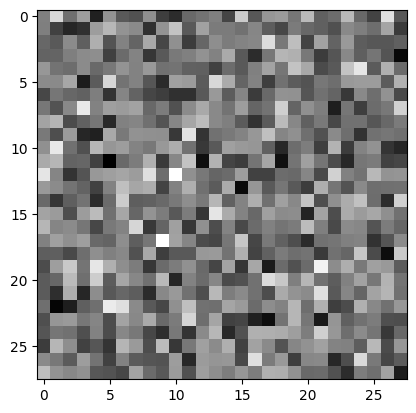

In [44]:
show_image(perturbed_images, idx=0)

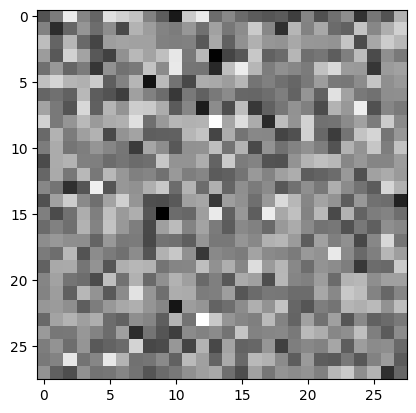

In [45]:
show_image(perturbed_images, idx=1)

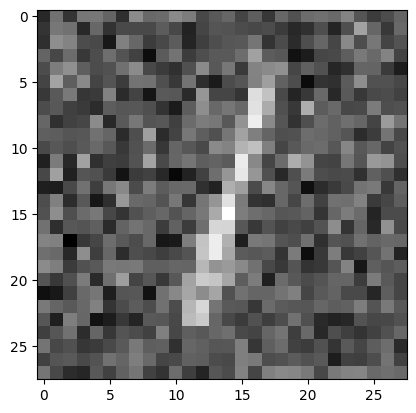

In [46]:
show_image(perturbed_images, idx=2)

In [47]:
print("Start training DDPMs...")
model.train()
loss_history = []
start_time = time.perf_counter()

for epoch in range(EPOCHS):
    noise_prediction_loss = 0.0
    for batch_idx, (x, _) in tqdm(enumerate(train_loader), total=len(train_loader)):
        optimizer.zero_grad(set_to_none=True)

        x = x.to(device, non_blocking=cuda)
        
        _, epsilon, pred_epsilon = model(x)
        loss = criterion(pred_epsilon, epsilon)
        
        noise_prediction_loss += loss.item()
        
        loss.backward()
        optimizer.step()
        
    avg_loss = noise_prediction_loss / (batch_idx + 1)
    loss_history.append(avg_loss)
    print("\tEpoch", epoch + 1, "complete!", "\tDenoising Loss: ", avg_loss)
    
training_time_sec = time.perf_counter() - start_time
best_loss = min(loss_history) if loss_history else float("nan")
print(f"Training time (s): {training_time_sec:.2f}")
print(f"Best denoising loss: {best_loss:.6f}")
print("Finish!!")

Start training DDPMs...


100%|██████████| 469/469 [05:42<00:00,  1.37it/s]

	Epoch 1 complete! 	Denoising Loss:  0.06695089006284152



100%|██████████| 469/469 [05:45<00:00,  1.36it/s]

	Epoch 2 complete! 	Denoising Loss:  0.0341701153665781


...

	Epoch 18 complete! 	Denoising Loss:  0.024163373247551512



100%|██████████| 469/469 [05:46<00:00,  1.35it/s]

	Epoch 19 complete! 	Denoising Loss:  0.02428215675389589



100%|██████████| 469/469 [05:46<00:00,  1.35it/s]

	Epoch 20 complete! 	Denoising Loss:  0.024128657521437735
Training time (s): 6921.81
Best denoising loss: 0.024129
Finish!!


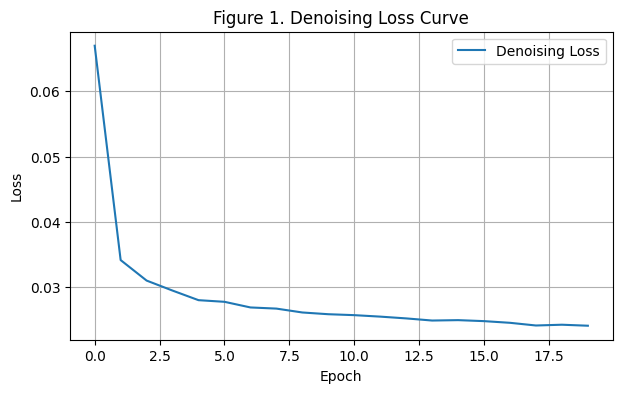

In [48]:
plt.figure(figsize=(7, 4))
plt.plot(loss_history, label="Denoising Loss")
plt.title("Figure 1. Denoising Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

In [49]:
torch.save(
    {
        "model_state_dict": model.state_dict(),
        "diffusion": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "epoch": EPOCHS,
        "config": {
            "img_size": IMAGE_SIZE,
            "n_timesteps": NUM_TIMESTEPS,
            "beta_minmax": BETA_MINMAX,
            "hidden_dims": HIDDEN_DIMS,
            "timestep_embedding_dim": T_EMB_DIM,
        },
    },
    CHECKPOINT_PATH,
 )
print(f"Saved checkpoint to {CHECKPOINT_PATH}")

Saved checkpoint to outputs/ddpm/ddpm_mnist.pt


In [50]:
use_pretrained = False
CHECKPOINT_PATH = "outputs/ddpm3_mnist.pth"
if use_pretrained and os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint["diffusion"])
    model.load_state_dict(checkpoint["model"])
    optimizer.load_state_dict(checkpoint["optimizer"])
    print(f"Loaded checkpoint from {CHECKPOINT_PATH}")
else:
    print("Using current model weights.")

Using current model weights.


In [51]:
model.eval()

with torch.no_grad():
    generated_images, denoise_snapshots = model.sample_with_steps(
        N=EVAL_BATCH_SIZE, snapshot_every=200
    )

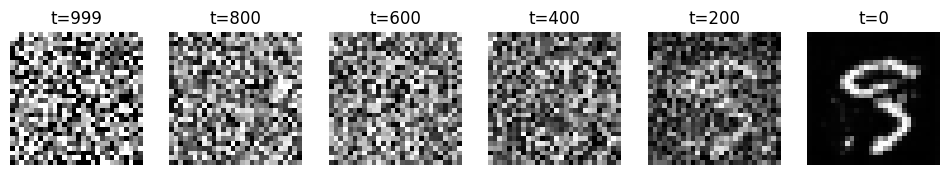

In [52]:
def show_denoise_steps(snapshots, idx=0):
    if len(snapshots) == 0:
        print("No snapshots to display.")
        return
    fig, axes = plt.subplots(1, len(snapshots), figsize=(2 * len(snapshots), 2))
    if len(snapshots) == 1:
        axes = [axes]
    for ax, (t, batch) in zip(axes, snapshots):
        img = batch[idx]
        if img.shape[0] == 1:
            ax.imshow(img.squeeze(0), cmap="gray")
        else:
            ax.imshow(img.permute(1, 2, 0))
        ax.set_title(f"t={t}")
        ax.axis("off")
    plt.show()

show_denoise_steps(denoise_snapshots, idx=0)

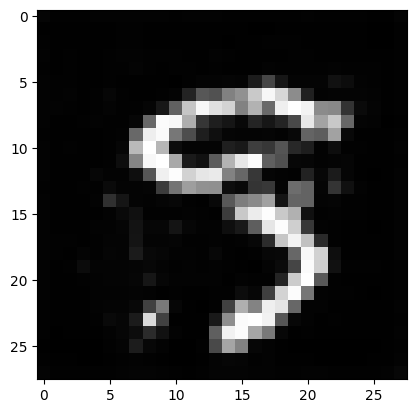

In [53]:
show_image(generated_images, idx=0)

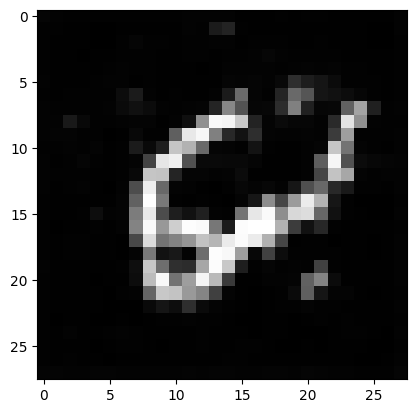

In [54]:
show_image(generated_images, idx=1)

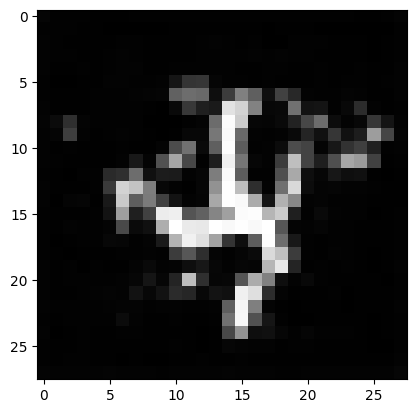

In [55]:
show_image(generated_images, idx=2)

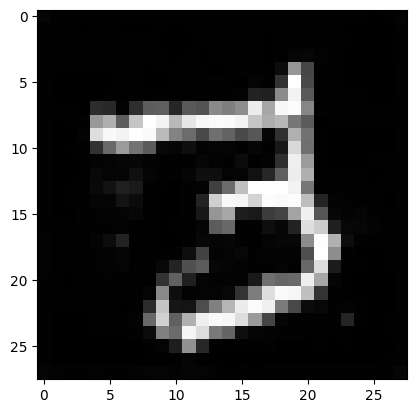

In [56]:
show_image(generated_images, idx=3)

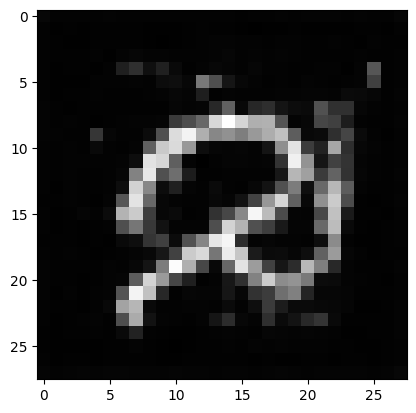

In [57]:
show_image(generated_images, idx=4)

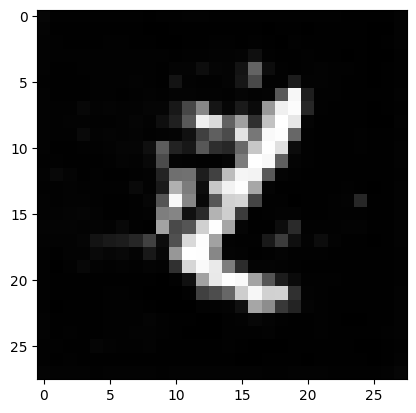

In [58]:
show_image(generated_images, idx=5)

### Comparison with ground-truth samples

In [59]:
real_batch, _ = next(iter(test_loader))
real_batch = real_batch.to(device)

In [60]:
def draw_sample_image(x, postfix):
  
    plt.figure(figsize=(8, 8))
    plt.axis("off")
    plt.title(f"Visualization of {postfix}")
    grid = make_grid(x.detach().cpu(), padding=2, normalize=True)
    grid = grid.permute(1, 2, 0).numpy()
    if grid.shape[2] == 1:
        plt.imshow(grid.squeeze(2), cmap="gray")
    else:
        plt.imshow(grid)

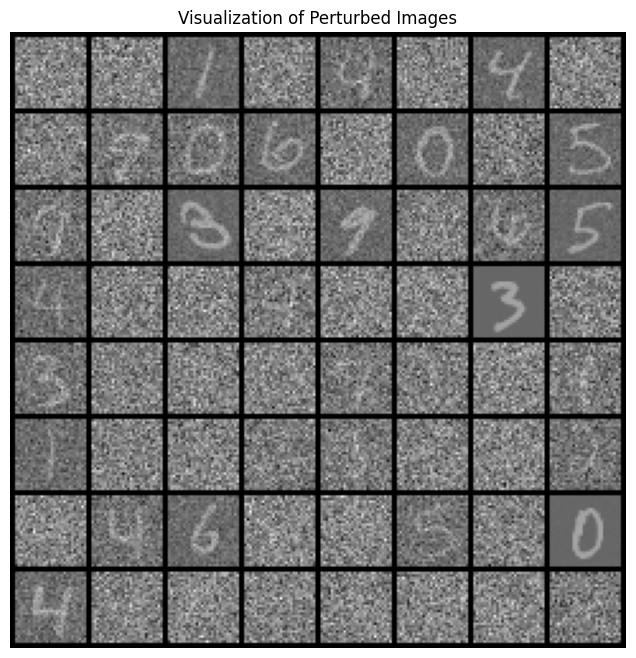

In [61]:
draw_sample_image(perturbed_images, "Perturbed Images")

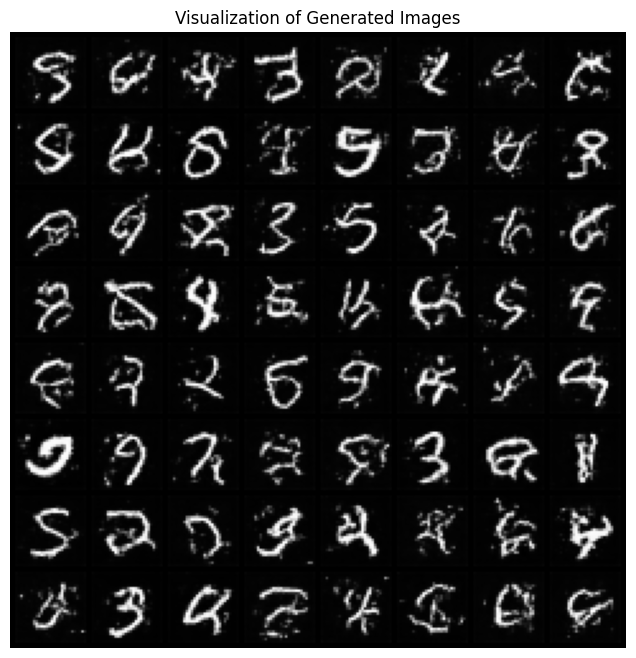

In [62]:
draw_sample_image(generated_images, "Generated Images")

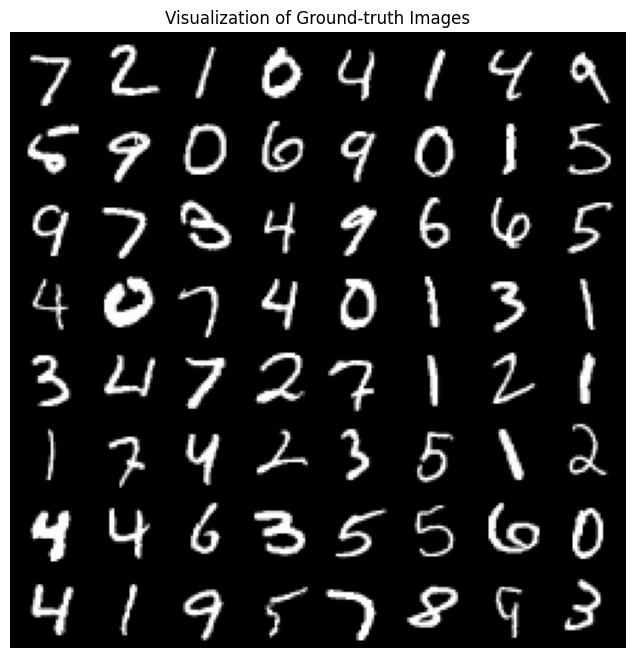

In [63]:
draw_sample_image(real_batch[:EVAL_BATCH_SIZE], "Ground-truth Images")

In [64]:
eval_count = min(EVAL_BATCH_SIZE, generated_images.shape[0], real_batch.shape[0])
real_eval = real_batch[:eval_count].clamp(0, 1)
fake_eval = generated_images[:eval_count].clamp(0, 1)

ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

def prepare_for_fid(x):
    if x.shape[1] == 1:
        x = x.repeat(1, 3, 1, 1)
    x = F.interpolate(x, size=(299, 299), mode="bilinear", align_corners=False)
    return x

fid_metric = FrechetInceptionDistance(feature=2048, normalize=True).to(device)
real_fid = prepare_for_fid(real_eval)
fake_fid = prepare_for_fid(fake_eval)

with torch.no_grad():
    ssim_score = ssim_metric(fake_eval, real_eval).item()
    fid_metric.update(real_fid, real=True)
    fid_metric.update(fake_fid, real=False)
    fid_score = fid_metric.compute().item()

print(f"SSIM (avg over {eval_count} samples): {ssim_score:.4f}")
print(f"FID  (avg over {eval_count} samples): {fid_score:.4f}")

SSIM (avg over 64 samples): 0.0659
FID  (avg over 64 samples): 168.9087


In [65]:
table1 = pd.DataFrame(
    {
        "Best Denoising Loss": [best_loss],
        "Training Time (s)": [training_time_sec],
        "SSIM": [ssim_score],
        "FID": [fid_score],
    },
    index=["Table 1"],
)
table1 = table1.round(
    {
        "Best Denoising Loss": 6,
        "Training Time (s)": 2,
        "SSIM": 4,
        "FID": 4,
    }
)
table1

,Best Denoising Loss,Training Time (s),SSIM,FID
Table 1,0.024129,6921.81,0.0659,168.9087
